In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression 
from pypfopt import risk_models, EfficientFrontier, expected_returns
import yfinance as yf

In [1]:
!pip install yfinance==0.2.47


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
risk_free_rate = 0.02  # Risk free rate

In [24]:
assets = ["AAPL", "MSFT", "GOOG", "AMZN", "TSLA"]
start_date = "2015-01-01"
end_date = "2025-01-01"
data = yf.download(assets, start=start_date, end=end_date, interval='1D', auto_adjust=False)['Adj Close']

[*********************100%***********************]  5 of 5 completed


In [ ]:
# convert index to YYYY-MM-DD format
# data.columns

Index(['AAPL', 'AMZN', 'GOOG', 'MSFT', 'TSLA'], dtype='object', name='Ticker')

In [39]:
import datetime
def get_market_cap_on_date(ticker_symbol, date_str):
    """
    Get market capitalization of a stock on a specific date.
    
    :param ticker_symbol: Stock ticker symbol (e.g., "AAPL")
    :param date_str: Date in 'YYYY-MM-DD' format
    :return: Market capitalization on that date
    """
    stock = yf.Ticker(ticker_symbol)
    
    # Convert date string to datetime
    date = datetime.datetime.strptime(date_str, "%Y-%m-%d").date()
    
    # Get historical data (closing price)
    hist = stock.history(start=date_str, end=(date + datetime.timedelta(days=1)).strftime("%Y-%m-%d"))
    
    if hist.empty:
        return f"No data available for {ticker_symbol} on {date_str}"
    
    closing_price = hist["Close"].iloc[0]  # Get closing price on the given date
    
    # Get shares outstanding (current, might not be exact for the past)
    shares_outstanding = stock.info.get("sharesOutstanding", None)
    
    if shares_outstanding is None:
        return "Shares outstanding data not available"
    
    # Calculate market cap
    market_cap = closing_price * shares_outstanding
    return market_cap

In [40]:
date = data.index[0].strftime('%Y-%m-%d')
mcaps = {ticker: get_market_cap_on_date(ticker, date) for ticker in assets}

# to series
mcaps = pd.Series(mcaps)

In [41]:
window_length = 180

X = data[:-window_length]  # Features to predict returns
y = data.pct_change(window_length).shift(-window_length)[:-window_length]  # Target variable

In [42]:
len(X), len(y)

(2336, 2336)

In [43]:
# X.head(700)

In [51]:
train_end_date = '2022-12-31'

idx = 1900

X_train,y_train = X[:idx], y[:idx]  # include data till 2022-12-31
X_test, y_test = X[idx - 1:], y[idx - 1:]


mcaps = {ticker: get_market_cap_on_date(ticker, X_train.index[-1].strftime('%Y-%m-%d')) for ticker in assets}
mcaps = pd.Series(mcaps)

In [52]:
model = LinearRegression()
model.fit(X_train.values,y_train)

LinearRegression()

In [53]:
# Predict returns
y_pred = model.predict(X_test.values)

# R^2 score
r2 = model.score(X_test.values, y_test)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print(f"R^2: {r2} RMSE: {rmse}")

R^2: -15.286100778549013 RMSE: 1.7359324693710634


In [54]:
y_pred[0],X_train.iloc[-1],y_test.iloc[0]

(array([-0.11192787,  0.10484608, -0.04705757, -0.04239448,  0.33786445]),
 Ticker
 AAPL    150.820999
 AMZN    122.769997
 GOOG    114.289345
 MSFT    256.765198
 TSLA    247.500000
 Name: 2022-07-20 00:00:00+00:00, dtype: float64,
 Ticker
 AAPL    0.080858
 AMZN   -0.168689
 GOOG   -0.050567
 MSFT    0.120130
 TSLA   -0.252283
 Name: 2022-07-20 00:00:00+00:00, dtype: float64)

In [55]:
# X_test.pct_change().dropna().head()

In [56]:
# data_returns

In [87]:
from pypfopt import black_litterman
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt.efficient_frontier import EfficientFrontier

# Initialize backtest parameters
initial_weights = mcaps / mcaps.sum()  # Market-cap weights
intial_investment = 10000  # Initial portfolio value
portfolio_value = [intial_investment]

data_returns = X_test.pct_change().dropna()
dates = X_test.index.to_list()

W = []

for i in range(int(len(data_returns) / window_length)):
    idx = i * window_length
    print("- - - -" * 5)
    # Q
    # print(X_test.iloc[i].to_numpy().reshape(1, -1))
    predicted_returns = model.predict(X_test.iloc[idx].to_numpy().reshape(1, -1))[0] # Predicted returns
    Q = pd.Series(predicted_returns, index=X_test.columns)
    # P
    P = np.eye(len(assets))  # Identity matrix

    viewdict = Q.to_dict()
    # S
    if idx == 0:
        S = risk_models.sample_cov(X_train)
    else:
        new_ = pd.concat([X_train, X_test[: idx]])
        S = risk_models.sample_cov(new_)

    # print(S)

    delta = 2.5  # Risk aversion
    prior = black_litterman.market_implied_prior_returns(mcaps, delta, S)

    bl = BlackLittermanModel(S, pi = prior, absolute_views=viewdict)
    bl_returns = bl.bl_returns()
    ef = EfficientFrontier(bl_returns, S)
    # add constraints
    # ef.add_constraint(lambda x : x >= 0.05)

    # try different objective functions
    ef.min_volatility()


    cleaned_weights = ef.clean_weights()

    # print(cleaned_weights)
    # print(len(portfolio_value))
    # returns based on the weights
    if i == int(len(data_returns)/window_length) - 1:
        portfolio_return = (data_returns.iloc[idx:] * cleaned_weights).sum(axis=1)
    else:
        portfolio_return = (data_returns.iloc[idx:idx+window_length] * cleaned_weights).sum(axis=1)

    for j in range(len(portfolio_return)):
        portfolio_value.append(portfolio_value[-1] * (1 + portfolio_return.iloc[j]))
    

    print(len(portfolio_return))
    W.append(cleaned_weights)

    # print(f"Portfolio value: {portfolio_value[-1]}")
print(len(portfolio_value))

- - - -- - - -- - - -- - - -- - - -
180
- - - -- - - -- - - -- - - -- - - -
256
437


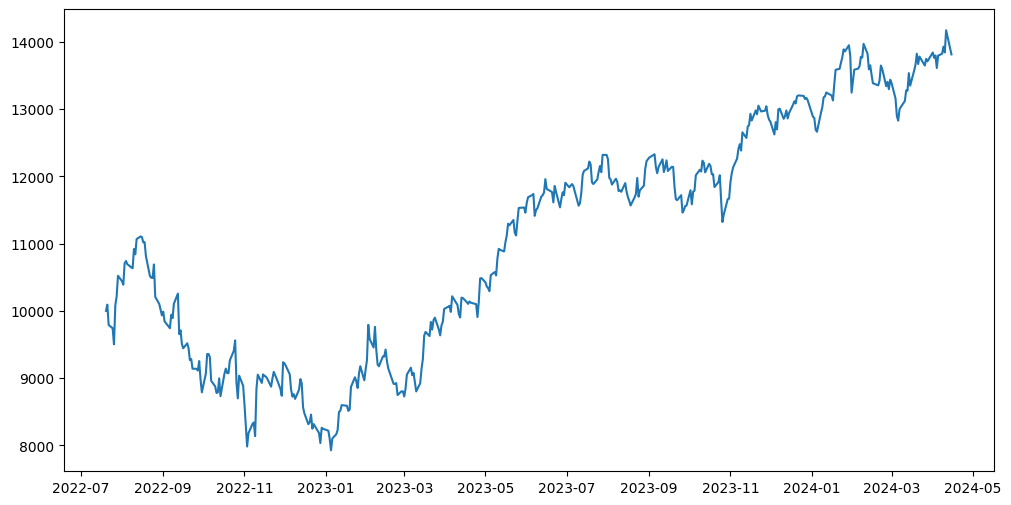

In [88]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(dates,portfolio_value, label='Portfolio Value')

In [89]:
len(W), len(portfolio_value), len(dates)

(2, 437, 437)

In [90]:
def get_sharpe_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    # print(annualized_return)
    annualized_volatility = portfolio_value.pct_change().std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / annualized_volatility

def get_sortino_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    downside_volatility = portfolio_value.pct_change()[portfolio_value.pct_change() < 0].std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / downside_volatility

def get_max_drawdown(portfolio_value):
    drawdown =  []
    peak = portfolio_value[0]

    for i in range(len(portfolio_value)):
        if portfolio_value[i] >= peak:
            peak = portfolio_value[i]
            drawdown.append(0)
        else:
            drawdown.append((portfolio_value[i] - peak) / peak)
    
    return drawdown





In [91]:
print(get_sharpe_ratio(pd.Series(portfolio_value, index=dates)))
print(get_sortino_ratio(pd.Series(portfolio_value, index=dates)))

0.7142645381087802
1.1082827199786351


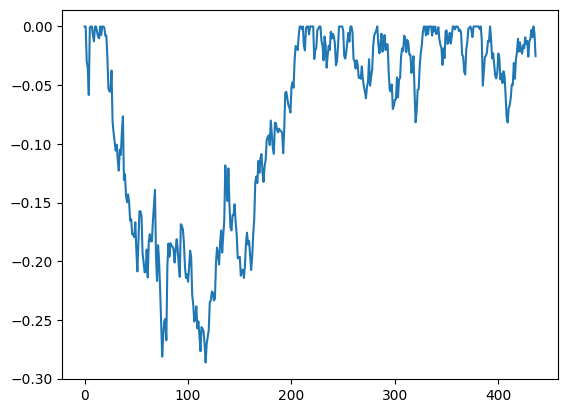

In [92]:
plt.plot(get_max_drawdown(portfolio_value), label="Equal Weights")

In [93]:
# plot weights
prior

Ticker
AAPL    0.174527
AMZN    0.180505
GOOG    0.153199
MSFT    0.166589
TSLA    0.251394
dtype: float64

In [94]:
# plot tsla
W

[OrderedDict([('AAPL', 0.25321),
              ('AMZN', 0.10416),
              ('GOOG', 0.36658),
              ('MSFT', 0.27604),
              ('TSLA', 0.0)]),
 OrderedDict([('AAPL', 0.29158),
              ('AMZN', 0.0873),
              ('GOOG', 0.32347),
              ('MSFT', 0.29765),
              ('TSLA', 0.0)])]